# 5.6 Case Study: End-to-End Visualization and Reporting Project

## 📋 Project Overview

This case study demonstrates a complete data visualization and reporting workflow, simulating a real-world business scenario.

### Case Study: E-Commerce Sales Analytics Dashboard

**Scenario:** You are a Data Analyst at "TechMart", an online electronics retailer. The management wants a comprehensive sales report with visualizations to understand business performance and make data-driven decisions.

### Project Objectives:
1. Analyze sales performance across different dimensions
2. Identify trends, patterns, and anomalies
3. Generate actionable insights
4. Create a professional report with visualizations

## End-to-End Workflow

```
┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
│  1. DATA     │ → │  2. DATA     │ → │  3. DATA     │ → │  4. VISUAL-  │ → │  5. REPORT   │
│  COLLECTION  │    │  CLEANING    │    │  ANALYSIS    │    │  IZATION     │    │  GENERATION  │
└──────────────┘    └──────────────┘    └──────────────┘    └──────────────┘    └──────────────┘
     ↓                    ↓                   ↓                   ↓                   ↓
  Load Data         Handle Missing      Calculate KPIs      Create Charts      Export Report
  from Source       Clean Outliers      Statistical         Interactive        PDF/HTML
                    Format Data         Analysis            Dashboards         Presentation
```

### Tools Used:
- **Pandas**: Data manipulation
- **NumPy**: Numerical operations
- **Matplotlib & Seaborn**: Static visualizations
- **Plotly**: Interactive visualizations

In [31]:
# Step 0: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully!")
print(f"📅 Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📅 Report Generated: 2026-01-30 11:23:46


---
## Step 1: Data Collection & Loading

In real projects, data comes from various sources:
- **Databases**: SQL queries
- **APIs**: REST/GraphQL endpoints
- **Files**: CSV, Excel, JSON
- **Web Scraping**: BeautifulSoup, Selenium

For this case study, we'll generate realistic e-commerce data.

In [32]:
# Step 1: Generate Realistic E-Commerce Dataset
np.random.seed(42)

# Generate 1000 orders over 12 months
n_orders = 1000
start_date = datetime(2024, 1, 1)

# Create order data
data = {
    'Order_ID': [f'ORD-{1000+i}' for i in range(n_orders)],
    'Order_Date': [start_date + timedelta(days=np.random.randint(0, 365)) for _ in range(n_orders)],
    'Customer_ID': [f'CUST-{np.random.randint(100, 500)}' for _ in range(n_orders)],
    'Product_Category': np.random.choice(
        ['Smartphones', 'Laptops', 'Tablets', 'Accessories', 'Wearables'], 
        n_orders, 
        p=[0.30, 0.25, 0.15, 0.20, 0.10]
    ),
    'Product_Name': None,  # Will be filled based on category
    'Quantity': np.random.randint(1, 5, n_orders),
    'Unit_Price': None,  # Will be filled based on category
    'Region': np.random.choice(['North', 'South', 'East', 'West', 'Central'], n_orders),
    'Payment_Method': np.random.choice(['Credit Card', 'Debit Card', 'UPI', 'COD', 'Net Banking'], n_orders),
    'Customer_Rating': np.random.choice([1, 2, 3, 4, 5], n_orders, p=[0.02, 0.05, 0.15, 0.38, 0.40])
}

# Create DataFrame
df = pd.DataFrame(data)

# Set realistic prices by category
price_map = {
    'Smartphones': (15000, 80000),
    'Laptops': (35000, 150000),
    'Tablets': (15000, 60000),
    'Accessories': (500, 5000),
    'Wearables': (2000, 25000)
}

product_names = {
    'Smartphones': ['iPhone 15', 'Samsung S24', 'OnePlus 12', 'Pixel 8', 'Xiaomi 14'],
    'Laptops': ['MacBook Pro', 'Dell XPS', 'HP Spectre', 'Lenovo ThinkPad', 'ASUS ROG'],
    'Tablets': ['iPad Pro', 'Samsung Tab', 'Lenovo Tab', 'Surface Pro', 'Xiaomi Pad'],
    'Accessories': ['Wireless Earbuds', 'Phone Case', 'Charger', 'Screen Guard', 'Power Bank'],
    'Wearables': ['Apple Watch', 'Galaxy Watch', 'Fitbit', 'Garmin', 'Mi Band']
}

# Fill product names and prices
for idx, row in df.iterrows():
    category = row['Product_Category']
    df.at[idx, 'Product_Name'] = np.random.choice(product_names[category])
    df.at[idx, 'Unit_Price'] = np.random.randint(price_map[category][0], price_map[category][1])

# Calculate derived columns
df['Total_Amount'] = df['Quantity'] * df['Unit_Price']
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Day'] = df['Order_Date'].dt.day_name()
df['Order_Quarter'] = df['Order_Date'].dt.quarter

# Add some missing values for realistic data (5% missing ratings)
missing_idx = np.random.choice(df.index, size=int(0.05 * n_orders), replace=False)
df.loc[missing_idx, 'Customer_Rating'] = np.nan

print("✅ Dataset Generated Successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📅 Date Range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")
df.head(10)

✅ Dataset Generated Successfully!
📊 Shape: 1000 rows × 14 columns
📅 Date Range: 2024-01-01 to 2024-12-30


,Order_ID,Order_Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price,Region,Payment_Method,Customer_Rating,Total_Amount,Order_Month,Order_Day,Order_Quarter
0,ORD-1000,2024-04-12,CUST-358,Accessories,Phone Case,2,4766,Central,Credit Card,5.0,9532,4,Friday,2
1,ORD-1001,2024-12-14,CUST-260,Accessories,Charger,2,3021,West,COD,4.0,6042,12,Saturday,4
2,ORD-1002,2024-09-27,CUST-489,Laptops,HP Spectre,3,86638,Central,Credit Card,5.0,259914,9,Friday,3
3,ORD-1003,2024-04-16,CUST-277,Laptops,HP Spectre,3,43418,West,Credit Card,4.0,130254,4,Tuesday,2
4,ORD-1004,2024-03-12,CUST-109,Laptops,Lenovo ThinkPad,1,64113,Central,COD,4.0,64113,3,Tuesday,1
5,ORD-1005,2024-07-07,CUST-360,Tablets,Surface Pro,2,29419,East,UPI,5.0,58838,7,Sunday,3
6,ORD-1006,2024-01-21,CUST-237,Smartphones,Xiaomi 14,2,25024,South,UPI,3.0,50048,1,Sunday,1
7,ORD-1007,2024-04-12,CUST-271,Laptops,MacBook Pro,2,144236,West,Debit Card,4.0,288472,4,Friday,2
8,ORD-1008,2024-05-01,CUST-485,Tablets,Xiaomi Pad,3,22435,North,Credit Card,4.0,67305,5,Wednesday,2
9,ORD-1009,2024-08-02,CUST-112,Tablets,Xiaomi Pad,2,20065,South,COD,2.0,40130,8,Friday,3


---
## Step 2: Data Cleaning & Preprocessing

Essential data cleaning steps:
1. Handle missing values
2. Check for duplicates
3. Fix data types
4. Handle outliers
5. Validate data integrity

In [33]:
# Step 2: Data Quality Check and Cleaning

print("=" * 60)
print("📋 DATA QUALITY REPORT")
print("=" * 60)

# 2.1 Check Missing Values
print("\n1️⃣ Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# 2.2 Check Duplicates
duplicates = df.duplicated().sum()
print(f"\n2️⃣ Duplicate Rows: {duplicates}")

# 2.3 Data Types
print("\n3️⃣ Data Types:")
print(df.dtypes)

# 2.4 Handle Missing Values - Fill with median rating
df['Customer_Rating'].fillna(df['Customer_Rating'].median(), inplace=True)
print(f"\n✅ Missing ratings filled with median: {df['Customer_Rating'].median()}")

# 2.5 Statistical Summary
print("\n4️⃣ Numerical Summary:")
print(df.describe().round(2))

print("\n" + "=" * 60)
print("✅ Data Cleaning Complete!")
print("=" * 60)

📋 DATA QUALITY REPORT

1️⃣ Missing Values:
                 Missing Count  Percentage
Customer_Rating             50         5.0

2️⃣ Duplicate Rows: 0

3️⃣ Data Types:
Order_ID                       str
Order_Date          datetime64[us]
Customer_ID                    str
Product_Category               str
Product_Name                object
Quantity                     int32
Unit_Price                  object
Region                         str
Payment_Method                 str
Customer_Rating            float64
Total_Amount                object
Order_Month                  int32
Order_Day                      str
Order_Quarter                int32
dtype: object

✅ Missing ratings filled with median: 4.0

4️⃣ Numerical Summary:
                       Order_Date  Quantity  Customer_Rating  Order_Month  \
count                        1000   1000.00           950.00      1000.00   
mean   2024-06-30 13:22:04.800000      2.49             4.06         6.51   
min           2024-01-01 00:0

---
## Step 3: Exploratory Data Analysis (EDA)

Calculate key business metrics and understand data distributions.

In [34]:
# Step 3: Calculate Key Performance Indicators (KPIs)

print("=" * 60)
print("📊 KEY PERFORMANCE INDICATORS (KPIs)")
print("=" * 60)

# Revenue Metrics
total_revenue = df['Total_Amount'].sum()
avg_order_value = df['Total_Amount'].mean()
total_orders = len(df)
total_customers = df['Customer_ID'].nunique()

# Product Metrics
total_units_sold = df['Quantity'].sum()
avg_units_per_order = df['Quantity'].mean()

# Customer Metrics
avg_rating = df['Customer_Rating'].mean()
repeat_customers = df['Customer_ID'].value_counts()
repeat_rate = (repeat_customers[repeat_customers > 1].count() / total_customers * 100)

print(f"""
💰 REVENUE METRICS:
   • Total Revenue: ₹{total_revenue:,.0f}
   • Average Order Value: ₹{avg_order_value:,.0f}
   • Total Orders: {total_orders:,}

📦 PRODUCT METRICS:
   • Total Units Sold: {total_units_sold:,}
   • Average Units/Order: {avg_units_per_order:.2f}

👥 CUSTOMER METRICS:
   • Unique Customers: {total_customers}
   • Repeat Customer Rate: {repeat_rate:.1f}%
   • Average Rating: {avg_rating:.2f}/5.0
""")

# Store KPIs for reporting
kpis = {
    'Total Revenue': f'₹{total_revenue:,.0f}',
    'Total Orders': f'{total_orders:,}',
    'Avg Order Value': f'₹{avg_order_value:,.0f}',
    'Unique Customers': total_customers,
    'Avg Rating': f'{avg_rating:.2f}/5.0'
}

📊 KEY PERFORMANCE INDICATORS (KPIs)

💰 REVENUE METRICS:
   • Total Revenue: ₹111,811,296
   • Average Order Value: ₹111,811
   • Total Orders: 1,000

📦 PRODUCT METRICS:
   • Total Units Sold: 2,493
   • Average Units/Order: 2.49

👥 CUSTOMER METRICS:
   • Unique Customers: 363
   • Repeat Customer Rate: 78.2%
   • Average Rating: 4.06/5.0



---
## Step 4: Data Visualization

### 4.1 Revenue Analysis Dashboard

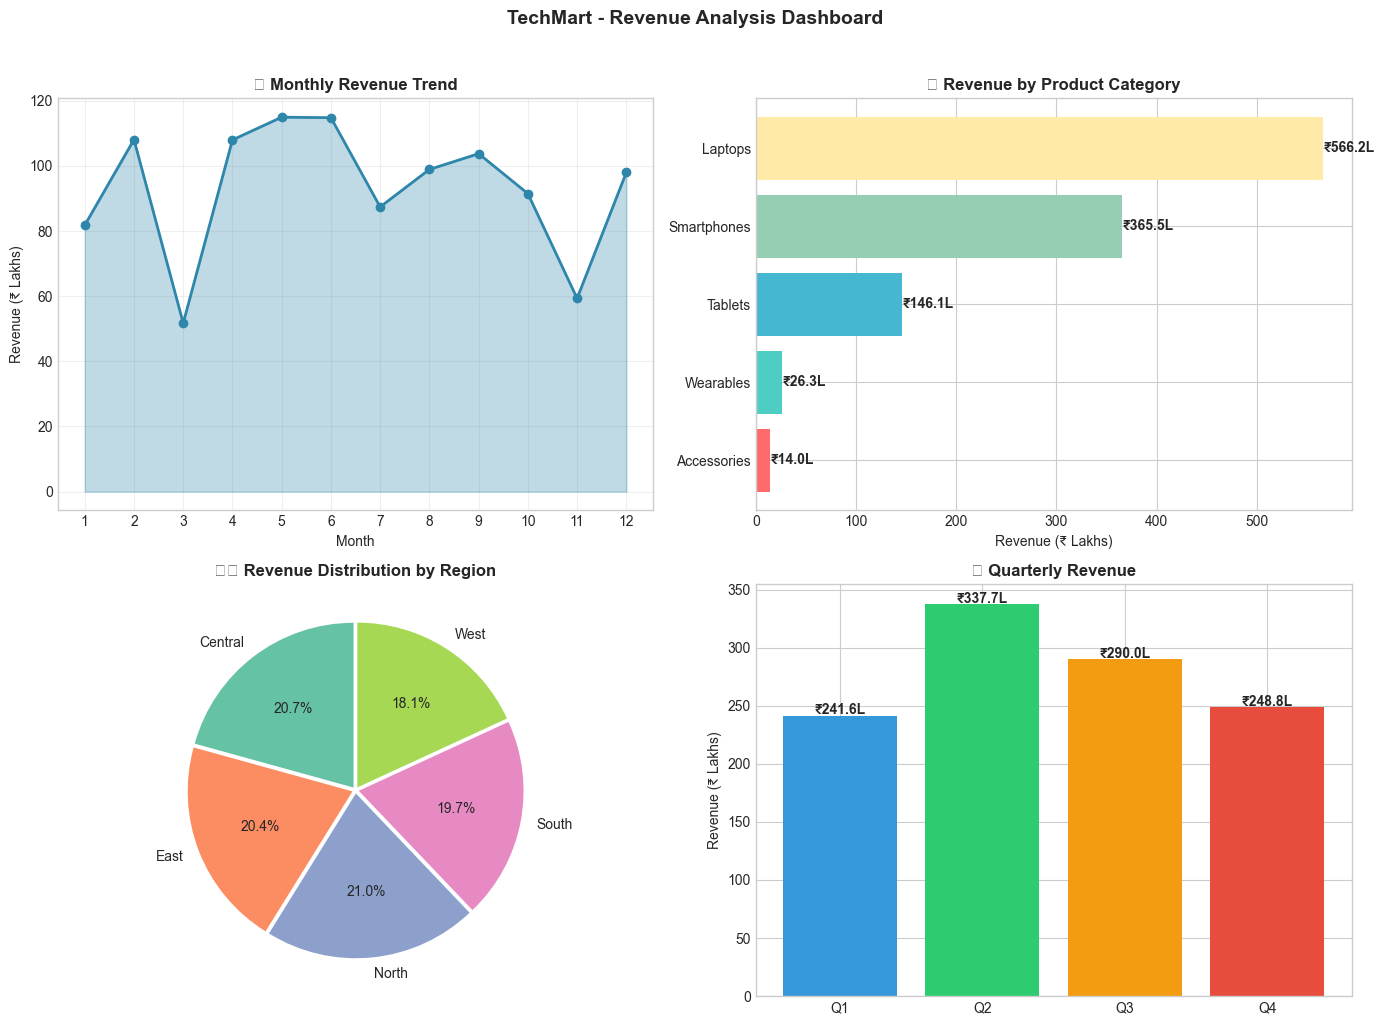


📊 REVENUE INSIGHTS:
   • Best Month: Month 5 (₹114.9L)
   • Top Category: Laptops (₹566.2L)
   • Top Region: North (21.0% share)
   • Best Quarter: Q2 (₹337.7L)


In [35]:
# 4.1 Revenue Analysis - Monthly Trend
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Monthly Revenue Trend
monthly_revenue = df.groupby('Order_Month')['Total_Amount'].sum() / 100000  # In Lakhs
months_list = list(monthly_revenue.index)
revenue_list = list(monthly_revenue.values)
axes[0, 0].plot(months_list, revenue_list, marker='o', linewidth=2, color='#2E86AB')
axes[0, 0].fill_between(months_list, revenue_list, alpha=0.3, color='#2E86AB')
axes[0, 0].set_title('📈 Monthly Revenue Trend', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Revenue (₹ Lakhs)')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].grid(True, alpha=0.3)

# Revenue by Category
category_revenue = df.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=True) / 100000
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
axes[0, 1].barh(category_revenue.index, category_revenue.values, color=colors)
axes[0, 1].set_title('📊 Revenue by Product Category', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Revenue (₹ Lakhs)')
for i, v in enumerate(category_revenue.values):
    axes[0, 1].text(v + 1, i, f'₹{v:.1f}L', va='center', fontweight='bold')

# Revenue by Region
region_revenue = df.groupby('Region')['Total_Amount'].sum() / 100000
axes[1, 0].pie(region_revenue.values, labels=region_revenue.index, autopct='%1.1f%%',
               colors=sns.color_palette('Set2'), startangle=90, explode=[0.02]*5)
axes[1, 0].set_title('🗺️ Revenue Distribution by Region', fontsize=12, fontweight='bold')

# Quarterly Revenue
quarterly_revenue = df.groupby('Order_Quarter')['Total_Amount'].sum() / 100000
quarter_labels = ['Q1', 'Q2', 'Q3', 'Q4']
bars = axes[1, 1].bar(quarter_labels, quarterly_revenue.values, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
axes[1, 1].set_title('📅 Quarterly Revenue', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Revenue (₹ Lakhs)')
for bar, val in zip(bars, quarterly_revenue.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'₹{val:.1f}L', ha='center', fontweight='bold')

plt.suptitle('TechMart - Revenue Analysis Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Insights
print("\n📊 REVENUE INSIGHTS:")
print(f"   • Best Month: Month {monthly_revenue.idxmax()} (₹{monthly_revenue.max():.1f}L)")
print(f"   • Top Category: {category_revenue.idxmax()} (₹{category_revenue.max():.1f}L)")
print(f"   • Top Region: {region_revenue.idxmax()} ({region_revenue.max()/region_revenue.sum()*100:.1f}% share)")
print(f"   • Best Quarter: Q{quarterly_revenue.idxmax()} (₹{quarterly_revenue.max():.1f}L)")

### 4.2 Product Performance Analysis

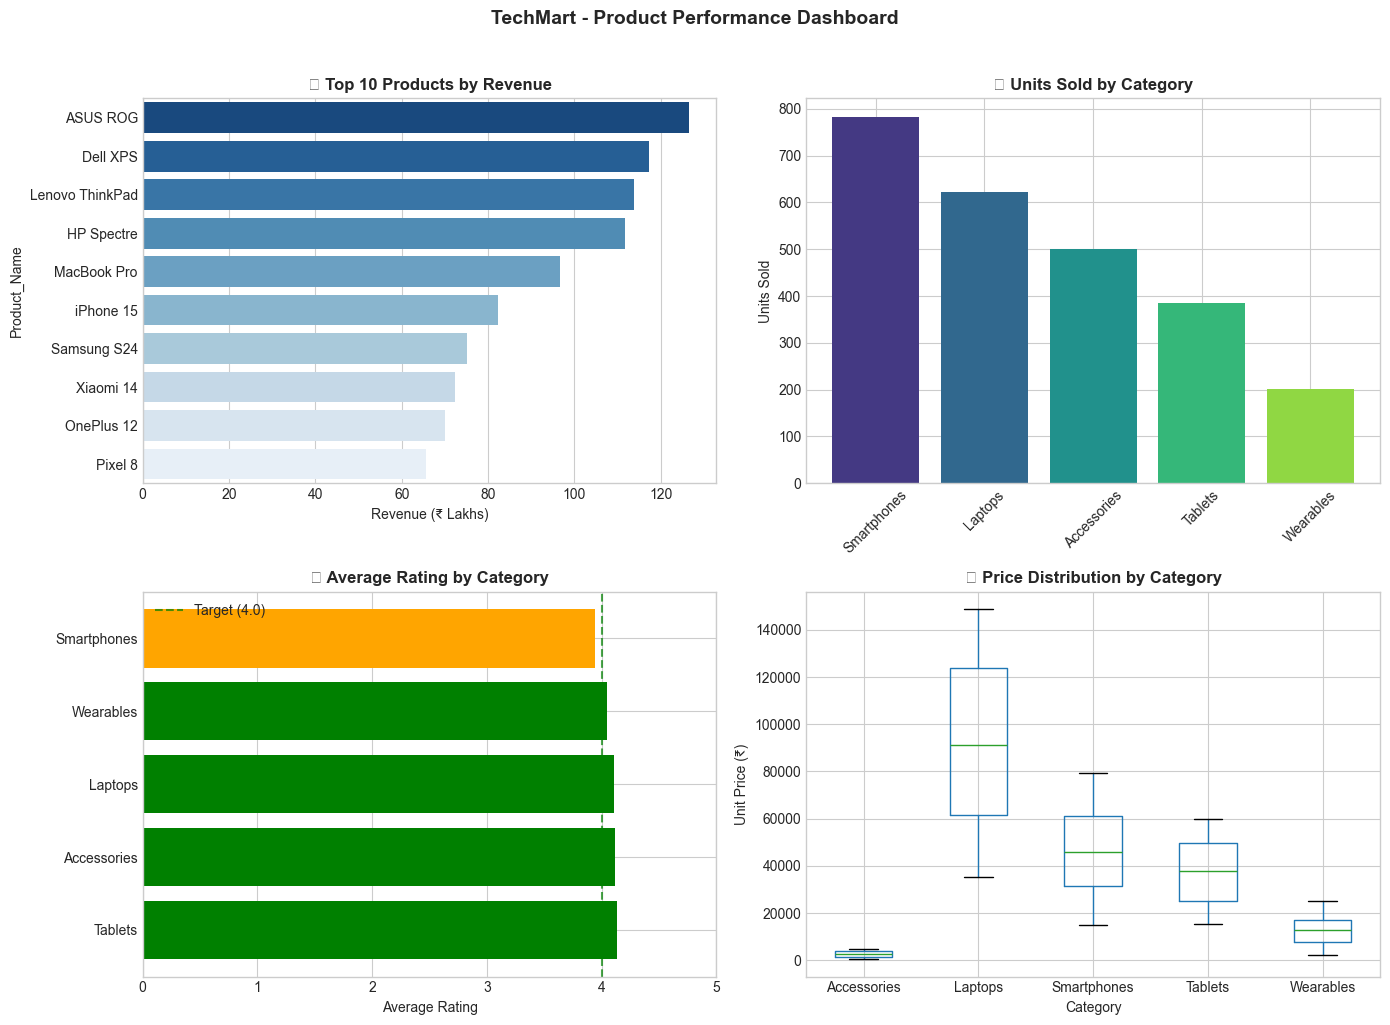


📦 PRODUCT INSIGHTS:
   • Best Selling Product: ASUS ROG (₹126.6L)
   • Most Units Sold: Smartphones (783 units)
   • Highest Rated Category: Tablets (4.13/5)


In [36]:
# 4.2 Product Performance Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 10 Products by Revenue
product_revenue = df.groupby('Product_Name')['Total_Amount'].sum().sort_values(ascending=False).head(10) / 100000
sns.barplot(x=product_revenue.values, y=product_revenue.index, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('🏆 Top 10 Products by Revenue', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Revenue (₹ Lakhs)')

# Units Sold by Category
units_by_category = df.groupby('Product_Category')['Quantity'].sum().sort_values(ascending=False)
axes[0, 1].bar(units_by_category.index, units_by_category.values, color=sns.color_palette('viridis', 5))
axes[0, 1].set_title('📦 Units Sold by Category', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Units Sold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Average Rating by Category
avg_rating_cat = df.groupby('Product_Category')['Customer_Rating'].mean().sort_values(ascending=False)
colors = ['green' if x >= 4 else 'orange' if x >= 3 else 'red' for x in avg_rating_cat.values]
axes[1, 0].barh(avg_rating_cat.index, avg_rating_cat.values, color=colors)
axes[1, 0].axvline(x=4, color='green', linestyle='--', alpha=0.7, label='Target (4.0)')
axes[1, 0].set_title('⭐ Average Rating by Category', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Average Rating')
axes[1, 0].set_xlim(0, 5)
axes[1, 0].legend()

# Price Distribution by Category (Box Plot)
df.boxplot(column='Unit_Price', by='Product_Category', ax=axes[1, 1])
axes[1, 1].set_title('💰 Price Distribution by Category', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Unit Price (₹)')
plt.suptitle('')  # Remove default title

plt.suptitle('TechMart - Product Performance Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Insights
print("\n📦 PRODUCT INSIGHTS:")
print(f"   • Best Selling Product: {product_revenue.index[0]} (₹{product_revenue.values[0]:.1f}L)")
print(f"   • Most Units Sold: {units_by_category.index[0]} ({units_by_category.values[0]:,} units)")
print(f"   • Highest Rated Category: {avg_rating_cat.index[0]} ({avg_rating_cat.values[0]:.2f}/5)")

### 4.3 Customer Behavior Analysis

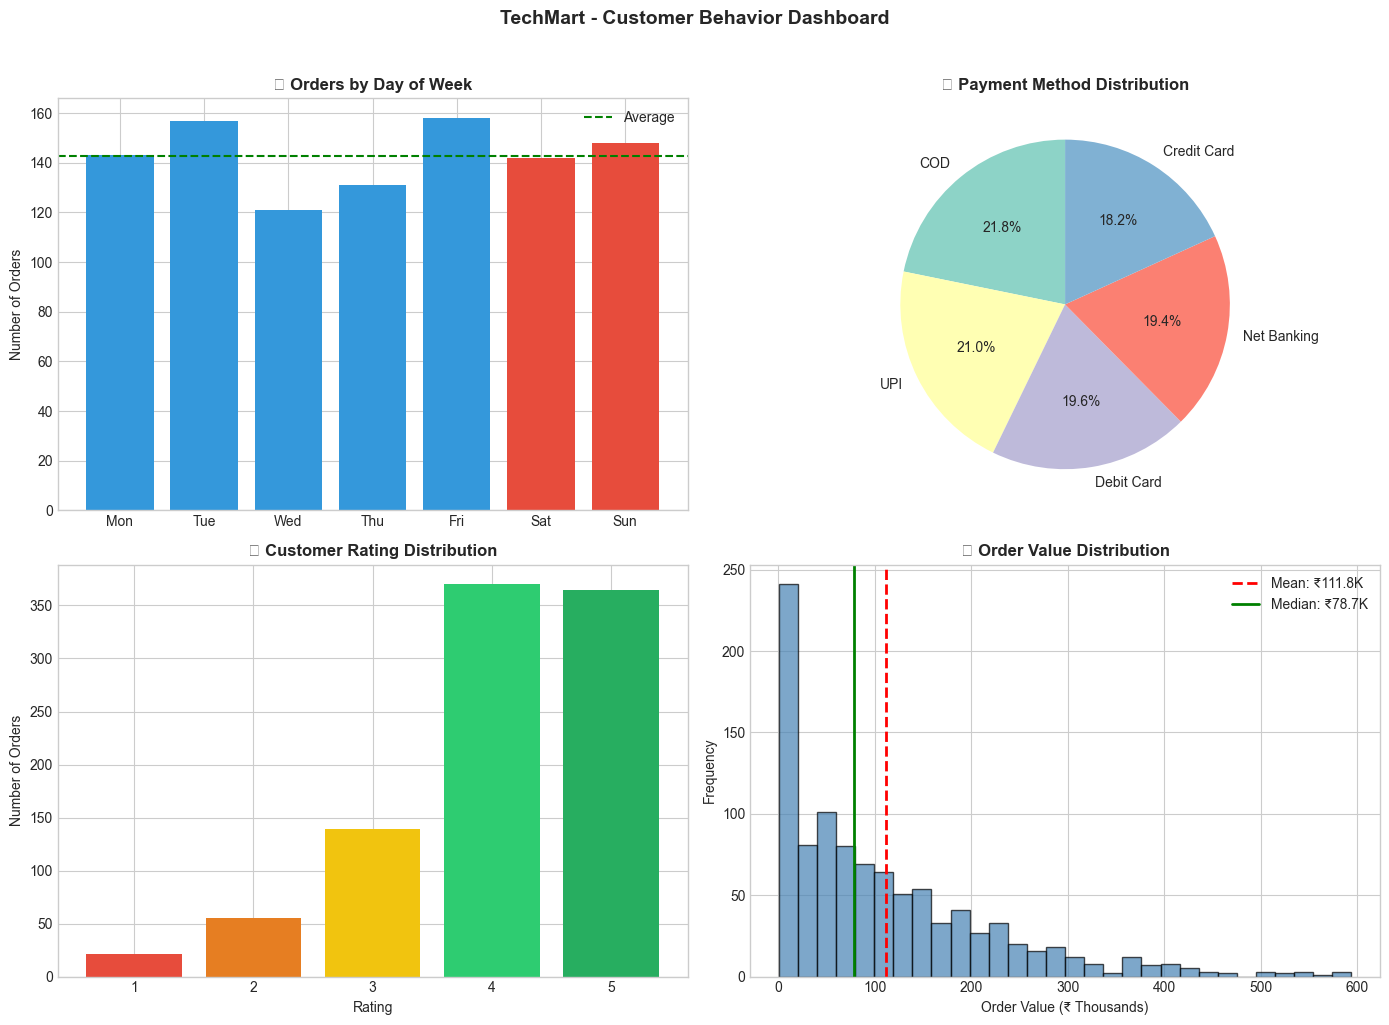


👥 CUSTOMER INSIGHTS:
   • Busiest Day: Friday (158 orders)
   • Most Popular Payment: COD (21.8%)
   • 4-5 Star Ratings: 73.5% of orders


In [37]:
# 4.3 Customer Behavior Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Orders by Day of Week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day = df['Order_Day'].value_counts().reindex(dow_order)
colors = ['#e74c3c' if day in ['Saturday', 'Sunday'] else '#3498db' for day in dow_order]
axes[0, 0].bar(range(7), orders_by_day.values, color=colors)
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0, 0].set_title('📅 Orders by Day of Week', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].axhline(y=orders_by_day.mean(), color='green', linestyle='--', label='Average')
axes[0, 0].legend()

# Payment Method Distribution
payment_dist = df['Payment_Method'].value_counts()
axes[0, 1].pie(payment_dist.values, labels=payment_dist.index, autopct='%1.1f%%',
               colors=sns.color_palette('Set3'), startangle=90)
axes[0, 1].set_title('💳 Payment Method Distribution', fontsize=12, fontweight='bold')

# Customer Rating Distribution
rating_dist = df['Customer_Rating'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[1, 0].bar(rating_dist.index, rating_dist.values, color=colors)
axes[1, 0].set_title('⭐ Customer Rating Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Number of Orders')
axes[1, 0].set_xticks([1, 2, 3, 4, 5])

# Order Value Distribution (Histogram)
axes[1, 1].hist(df['Total_Amount']/1000, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[1, 1].axvline(x=df['Total_Amount'].mean()/1000, color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: ₹{df['Total_Amount'].mean()/1000:.1f}K")
axes[1, 1].axvline(x=df['Total_Amount'].median()/1000, color='green', linestyle='-', 
                   linewidth=2, label=f"Median: ₹{df['Total_Amount'].median()/1000:.1f}K")
axes[1, 1].set_title('💵 Order Value Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Order Value (₹ Thousands)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.suptitle('TechMart - Customer Behavior Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Insights
print("\n👥 CUSTOMER INSIGHTS:")
print(f"   • Busiest Day: {orders_by_day.idxmax()} ({orders_by_day.max()} orders)")
print(f"   • Most Popular Payment: {payment_dist.index[0]} ({payment_dist.values[0]/len(df)*100:.1f}%)")
print(f"   • 4-5 Star Ratings: {(df['Customer_Rating'] >= 4).sum()/len(df)*100:.1f}% of orders")

### 4.4 Interactive Dashboard with Plotly

In [38]:
# 4.4 Interactive Dashboard with Plotly
# Create a comprehensive interactive dashboard

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Monthly Revenue Trend', 'Revenue by Category', 
                    'Revenue by Region', 'Category-wise Monthly Performance'),
    specs=[[{"type": "scatter"}, {"type": "pie"}],
           [{"type": "bar"}, {"type": "heatmap"}]]
)

# 1. Monthly Revenue Trend (Interactive Line)
monthly_rev = df.groupby('Order_Month')['Total_Amount'].sum() / 100000
fig.add_trace(
    go.Scatter(x=list(range(1, 13)), y=monthly_rev.values, 
               mode='lines+markers', name='Revenue',
               line=dict(color='#2E86AB', width=3),
               marker=dict(size=10)),
    row=1, col=1
)

# 2. Revenue by Category (Pie)
cat_rev = df.groupby('Product_Category')['Total_Amount'].sum()
fig.add_trace(
    go.Pie(labels=cat_rev.index, values=cat_rev.values, name='Category',
           hole=0.4, textinfo='percent+label'),
    row=1, col=2
)

# 3. Revenue by Region (Bar)
region_rev = df.groupby('Region')['Total_Amount'].sum() / 100000
fig.add_trace(
    go.Bar(x=region_rev.index, y=region_rev.values, name='Region',
           marker_color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']),
    row=2, col=1
)

# 4. Category-Month Heatmap
cat_month = df.pivot_table(values='Total_Amount', index='Product_Category', 
                            columns='Order_Month', aggfunc='sum') / 100000
cat_month_array = np.array(cat_month.values, dtype=float)
fig.add_trace(
    go.Heatmap(z=cat_month_array, x=list(range(1, 13)), 
               y=list(cat_month.index), colorscale='Blues',
               text=np.round(cat_month_array, 1), texttemplate='%{text}'),
    row=2, col=2
)

fig.update_layout(
    title_text='🛒 TechMart Interactive Sales Dashboard',
    title_font_size=20,
    showlegend=False,
    height=700
)
fig.show()

---
## Step 5: Insight Generation & Recommendations

In [39]:
# Step 5: Comprehensive Insights Report
print("=" * 80)
print("📊 TECHMART SALES ANALYTICS - EXECUTIVE SUMMARY")
print("=" * 80)

# Calculate all metrics
total_rev = df['Total_Amount'].sum()
monthly_growth = monthly_rev.pct_change().mean() * 100
top_category = df.groupby('Product_Category')['Total_Amount'].sum().idxmax()
top_region = df.groupby('Region')['Total_Amount'].sum().idxmax()
top_product = df.groupby('Product_Name')['Total_Amount'].sum().idxmax()
low_rating_pct = (df['Customer_Rating'] < 3).sum() / len(df) * 100

print(f"""
📈 PERFORMANCE HIGHLIGHTS:
{'─' * 40}
• Total Revenue: ₹{total_rev/10000000:.2f} Crores
• Total Orders: {len(df):,}
• Average Order Value: ₹{df['Total_Amount'].mean():,.0f}
• Average Monthly Growth: {monthly_growth:.1f}%

🏆 TOP PERFORMERS:
{'─' * 40}
• Best Category: {top_category}
• Best Region: {top_region}
• Best Product: {top_product}
• Customer Satisfaction: {df['Customer_Rating'].mean():.2f}/5.0

⚠️ AREAS OF CONCERN:
{'─' * 40}
• Low Ratings (<3 stars): {low_rating_pct:.1f}% of orders
• Lowest Region: {df.groupby('Region')['Total_Amount'].sum().idxmin()}
• Slowest Month: Month {monthly_rev.idxmin()}

💡 RECOMMENDATIONS:
{'─' * 40}
1. MARKETING: Focus campaigns on {top_category} - highest revenue generator
2. EXPANSION: Strengthen presence in {df.groupby('Region')['Total_Amount'].sum().idxmin()} region
3. INVENTORY: Stock up for Month {monthly_rev.idxmax()} - peak sales period
4. CUSTOMER SERVICE: Address {low_rating_pct:.1f}% low-rated orders
5. PAYMENT: Promote {df['Payment_Method'].value_counts().index[0]} - most preferred method
""")

print("=" * 80)

📊 TECHMART SALES ANALYTICS - EXECUTIVE SUMMARY

📈 PERFORMANCE HIGHLIGHTS:
────────────────────────────────────────
• Total Revenue: ₹11.18 Crores
• Total Orders: 1,000
• Average Order Value: ₹111,811
• Average Monthly Growth: 9.8%

🏆 TOP PERFORMERS:
────────────────────────────────────────
• Best Category: Laptops
• Best Region: North
• Best Product: ASUS ROG
• Customer Satisfaction: 4.06/5.0

⚠️ AREAS OF CONCERN:
────────────────────────────────────────
• Low Ratings (<3 stars): 7.6% of orders
• Lowest Region: West
• Slowest Month: Month 3

💡 RECOMMENDATIONS:
────────────────────────────────────────
1. MARKETING: Focus campaigns on Laptops - highest revenue generator
2. EXPANSION: Strengthen presence in West region
3. INVENTORY: Stock up for Month 5 - peak sales period
4. CUSTOMER SERVICE: Address 7.6% low-rated orders
5. PAYMENT: Promote COD - most preferred method



---
## Step 6: Report Generation & Export

In real projects, reports can be exported as:
- **PDF**: Using libraries like `reportlab` or `fpdf`
- **HTML**: Interactive reports with Plotly
- **Excel**: Using `openpyxl` or `xlsxwriter`
- **PowerPoint**: Using `python-pptx`

In [40]:
# Step 6: Export Summary Data for Reporting

# Create summary DataFrames for export
monthly_summary = df.groupby('Order_Month').agg({
    'Total_Amount': ['sum', 'mean', 'count'],
    'Quantity': 'sum',
    'Customer_Rating': 'mean'
}).round(2)
monthly_summary.columns = ['Total_Revenue', 'Avg_Order_Value', 'Order_Count', 'Units_Sold', 'Avg_Rating']

category_summary = df.groupby('Product_Category').agg({
    'Total_Amount': ['sum', 'mean'],
    'Quantity': 'sum',
    'Customer_Rating': 'mean'
}).round(2)
category_summary.columns = ['Total_Revenue', 'Avg_Order_Value', 'Units_Sold', 'Avg_Rating']

region_summary = df.groupby('Region').agg({
    'Total_Amount': ['sum', 'mean'],
    'Order_ID': 'count',
    'Customer_Rating': 'mean'
}).round(2)
region_summary.columns = ['Total_Revenue', 'Avg_Order_Value', 'Order_Count', 'Avg_Rating']

print("📋 MONTHLY SUMMARY TABLE:")
print(monthly_summary)
print("\n📋 CATEGORY SUMMARY TABLE:")
print(category_summary)
print("\n📋 REGION SUMMARY TABLE:")
print(region_summary)

# Export to CSV (uncomment to use)
# monthly_summary.to_csv('monthly_summary.csv')
# category_summary.to_csv('category_summary.csv')
# region_summary.to_csv('region_summary.csv')
# print("\n✅ Summary tables exported to CSV files!")

📋 MONTHLY SUMMARY TABLE:
            Total_Revenue Avg_Order_Value  Order_Count  Units_Sold  Avg_Rating
Order_Month                                                                   
1                 8177997   104846.115385           78         209        4.06
2                10806308   117459.869565           92         235        3.78
3                 5173003    87678.016949           59         141        4.11
4                10796556   117353.869565           92         225        4.16
5                11494827       114948.27          100         246        4.13
6                11478675   145299.683544           79         206        3.99
7                 8739685   114995.855263           76         187        3.87
8                 9890652    96025.747573          103         257        4.06
9                10373480   124981.686747           83         210        4.18
10                9147967   115797.050633           79         192        4.12
11                5932604  

---
## Summary: End-to-End Visualization Project Workflow

### Project Lifecycle

| Step | Phase | Activities | Tools |
|------|-------|------------|-------|
| 1 | **Data Collection** | Gather data from sources | SQL, APIs, CSV |
| 2 | **Data Cleaning** | Handle missing values, outliers | Pandas |
| 3 | **EDA** | Calculate KPIs, statistics | Pandas, NumPy |
| 4 | **Visualization** | Create charts, dashboards | Matplotlib, Seaborn, Plotly |
| 5 | **Insights** | Derive actionable recommendations | Analysis |
| 6 | **Reporting** | Export and present findings | PDF, HTML, Excel |

### Key Learnings from this Case Study

1. **Data Quality is Crucial** - Always clean and validate data before analysis
2. **Choose Right Visualizations** - Match chart type to the insight you want to convey
3. **Tell a Story** - Visualizations should answer business questions
4. **Be Actionable** - Every insight should lead to a recommendation
5. **Use Multiple Views** - Combine static and interactive visualizations

### Types of Analysis Performed

| Analysis Type | Charts Used | Insights Derived |
|--------------|-------------|------------------|
| **Trend Analysis** | Line charts | Monthly growth patterns |
| **Comparison** | Bar charts | Category/Region performance |
| **Distribution** | Histogram, Box plots | Order value spread |
| **Composition** | Pie charts | Payment method share |
| **Correlation** | Heatmaps | Category-month relationships |

### Real-World Applications

- **E-commerce**: Sales dashboards, customer analytics
- **Finance**: Revenue reports, expense tracking
- **Healthcare**: Patient statistics, treatment outcomes
- **Marketing**: Campaign performance, ROI analysis
- **Education**: Student performance, enrollment trends

### Best Practices for Reporting

1. ✅ Start with an Executive Summary
2. ✅ Include Key KPIs upfront
3. ✅ Use consistent color schemes
4. ✅ Label charts clearly
5. ✅ Provide context for numbers
6. ✅ End with actionable recommendations